# UCB Capstone Project 
U.C. Berkeley Engineering Data Science Project
## Protien predictors for developing Alzheimers

### Kaggle Plasma lipidomics in Alzheimer's disease

[Kaggle Plasma lipidomics in Alzheimer's disease](https://www.kaggle.com/datasets/fereshtehjozaghkar/plasma-lipidomics-in-alzheimers-disease)


#### Data Card

##### About Datset

**Introduction**
Alzheimer's disease (AD) is a progressive neurodegenerative disorder that affects humans. It is typically characterized by cognitive impairment, which affects speech, behavior, and visual orientation. As cognitive capabilities decline, daily activities become more challenging, disabilities are experienced, and death occurs. Alzheimer's disease (AD) is strongly associated with abnormal lipid metabolism.
This dataset contains 213 plasma samples, including 20 controls, 89 samples from individuals with mild cognitive impairment, and 104 samples from individuals with Alzheimer's disease. Furthermore, the dataset includes information on age, sex, cognitive evaluation results, and cerebrospinal fluid biomarkers indicative of Alzheimer's disease.

**Authors**
Gerard Piñol-Ripoll, Farida Dakterzada, Joaquim Sol, Mariona Jové, Reinald Pamplona

**- Creative Commons License of the dataset:**
Attribution-NonCommercial-NoDerivatives (BY-NC-ND)

**- Dataset Digital Object Identifier (DOI):**
https://doi.org/10.34810/data614

**- Publications related to the dataset:**
Dakterzada, F., Jové, M., Huerto, R., Carnes, A., Sol, J., Pamplona, R., & Piñol-Ripoll, G. (2023). Changes in Plasma Neutral and Ether-Linked Lipids Are Associated with The Pathology and Progression of Alzheimer’s Disease. Aging and Disease, 14(5), 1728.

# Business Understanding
## Clinical Background

[Mayo Clinic](https://newsnetwork.mayoclinic.org/discussion/mayo-clinic-scientists-create-tool-to-predict-alzheimers-risk-years-before-symptoms-begin/)

Predicting Alzheimer's disease
Alzheimer's disease is marked by two key proteins in the brain: amyloid, which forms plaques, and tau, which forms tangles. Drugs recently approved by the Food and Drug Administration remove amyloid from the brain and can slow the rate of disease progression for people with MCI or mild dementia.

Photo of Dr. Clifford Jack, Jr.
Clifford Jack, Jr., M.D.
"What's exciting now is that we're looking even earlier — before symptoms begin — to see if we can predict who might be at greatest risk of developing cognitive problems in the future," says Clifford Jack, Jr., M.D., radiologist and lead author of the study.

The new prediction model combined several factors, including age, sex, genetic risk as associated with APOE genotype and brain amyloid levels detected on PET scans. Using the data, researchers can calculate an individual's likelihood of developing MCI or dementia within 10 years or over the predicted lifetime. Of all the predictors evaluated, the brain amyloid levels detected on PET scans was the predictor with the largest effect for lifetime risk of both MCI and dementia.

# Data Understanding 

In [1]:
import pandas as pd
import seaborn as sns
sns.set_palette("pastel")
import plotly.express as px
import matplotlib.pyplot as plt
import math
import numpy as np

pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
%matplotlib inline

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
#from xgboost import XGBClassifier
#from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV

In [3]:
import seaborn as sns

In [4]:
df = pd.read_csv("data/plasma_lipidomics.csv")

## 1. Data Analysis

In [5]:
df.head()

,Sample,Diagnostic,Sex,Age,MMSE,CSF Amyloid (pg/mL),CSF Total tau (pg/mL),CSF Phosphorylated tau (pg/mL),APOE4,Progression to Alzheimer's Disease,Progression time (months)
0,1,Alzheimer's Disease,Female,68,26,688.0,369.0,107.0,Yes,NaN,NaN
1,2,Alzheimer's Disease,Female,66,22,489.0,482.0,176.0,Yes,NaN,NaN
2,3,Alzheimer's Disease,Female,72,23,509.0,329.0,114.0,Yes,NaN,NaN
3,4,Alzheimer's Disease,Male,73,25,544.0,482.0,80.0,No,NaN,NaN
4,5,Alzheimer's Disease,Female,75,15,303.0,806.0,120.0,No,NaN,NaN


In [6]:
len(df)

212

In [7]:
def histogram(label,rotation=None):
    ax = sns.histplot(data=df,x=label,hue=label,legend=False, shrink=.9)
    if rotation:
        ax.tick_params(axis='x', labelrotation=rotation)
    # Add the counts on top of each bar automatically
    for container in ax.containers:
        ax.bar_label(container, fmt=lambda x: str(int(x)) if x > 0 else '')
    image_title = label.replace(" ", "_")
    plt.savefig(f"images/{image_title}", dpi=300, bbox_inches="tight")
    plt.show()

In [8]:
def histogram_totals(totals,title,xlabel):
    labels = ['Yes', 'No']   
    # 2. Create the bar plot
    plt.figure(figsize=(6, 4))
    ax = sns.barplot(x=labels, y=totals, palette=['#a1c9f4', '#ffb482'])
    for container in ax.containers:
            ax.bar_label(container, fmt=lambda x: str(int(x)) if x > 0 else '')
    # 3. Add labels and show
    plt.title(title)
    image_title = title.replace(" ", "_")
    plt.savefig(f"images/{image_title}", dpi=300, bbox_inches="tight")
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.show()

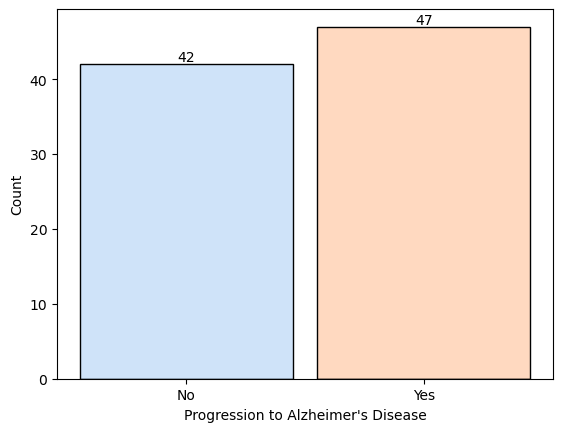

In [9]:
histogram("Progression to Alzheimer's Disease")

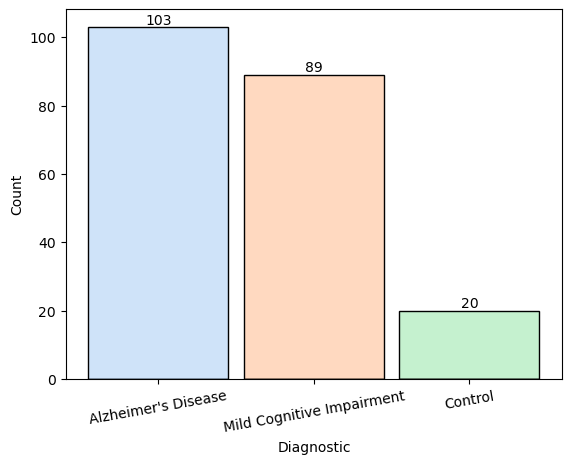

In [10]:
histogram("Diagnostic",rotation=10)

### Exploring the relationships between Diagnostic and the key indicator "Progression to Alzeimers's Disease"

In [11]:
overlap_yes = df[(df['Diagnostic'] == 'Mild Cognitive Impairment') & (df["Progression to Alzheimer's Disease"] == 'Yes')]
overlap_no  = df[(df['Diagnostic'] == 'Mild Cognitive Impairment') & (df["Progression to Alzheimer's Disease"] == 'No')]

print("Non-MCI patients with Progression = Yes:", len(overlap_yes))
print("Non-MCI patients with Progression = No:", len(overlap_no))

Non-MCI patients with Progression = Yes: 47
Non-MCI patients with Progression = No: 42


In [12]:
totals =[len(overlap_yes), len(overlap_no)]
totals

[47, 42]

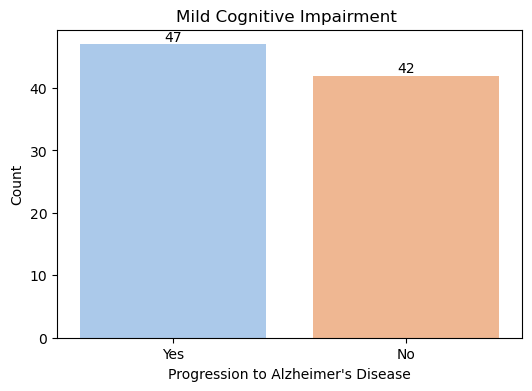

In [13]:
histogram_totals(totals=totals, title="Mild Cognitive Impairment ",xlabel="Progression to Alzheimer's Disease")

In [14]:
overlap_yes = df[(df['Diagnostic'] == "Alzheimer's Disease") & (df["Progression to Alzheimer's Disease"] == 'Yes')]
overlap_no  = df[(df['Diagnostic'] == "Alzheimer's Disease") & (df["Progression to Alzheimer's Disease"] == 'No')]

print("Non-MCI patients with Progression = Yes:", len(overlap_yes))
print("Non-MCI patients with Progression = No:", len(overlap_no))


Non-MCI patients with Progression = Yes: 0
Non-MCI patients with Progression = No: 0


In [15]:
df[df['Diagnostic'] == "Alzheimer's Disease"]

,Sample,Diagnostic,Sex,Age,MMSE,CSF Amyloid (pg/mL),CSF Total tau (pg/mL),CSF Phosphorylated tau (pg/mL),APOE4,Progression to Alzheimer's Disease,Progression time (months)
0,1,Alzheimer's Disease,Female,68,26,688.0,369.0,107.0,Yes,NaN,NaN
1,2,Alzheimer's Disease,Female,66,22,489.0,482.0,176.0,Yes,NaN,NaN
2,3,Alzheimer's Disease,Female,72,23,509.0,329.0,114.0,Yes,NaN,NaN
3,4,Alzheimer's Disease,Male,73,25,544.0,482.0,80.0,No,NaN,NaN
4,5,Alzheimer's Disease,Female,75,15,303.0,806.0,120.0,No,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
99,100,Alzheimer's Disease,Female,79,19,395.0,377.0,54.8,No,NaN,NaN
100,101,Alzheimer's Disease,Female,71,28,556.0,257.0,48.1,Yes,NaN,NaN
101,102,Alzheimer's Disease,Female,70,25,354.0,312.0,53.8,Yes,NaN,NaN
102,103,Alzheimer's Disease,Male,79,25,755.0,685.0,86.3,No,NaN,NaN


In [16]:
overlap_yes = df[(df['Diagnostic'] == "Control") & (df["Progression to Alzheimer's Disease"] == 'Yes')]
overlap_no  = df[(df['Diagnostic'] == "Control") & (df["Progression to Alzheimer's Disease"] == 'No')]

print("Non-MCI patients with Progression = Yes:", len(overlap_yes))
print("Non-MCI patients with Progression = No:", len(overlap_no))

Non-MCI patients with Progression = Yes: 0
Non-MCI patients with Progression = No: 0


## Key Observation


There are no patients who's Diagnostic is 'Alzheimer's Disease' or 'Control' "Progression to Alzheimer's Disease"

Therefore are two we will only consider Diagnostic "Mild Cognitive Impairment" and "Progression to Alzheimer's Disease" Yes or No

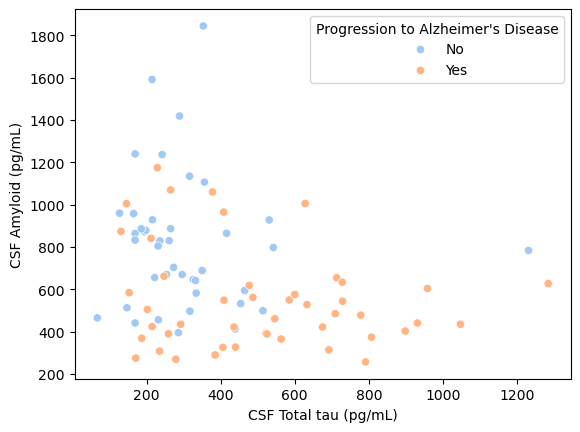

In [17]:
sns.scatterplot(data = df, x='CSF Total tau (pg/mL)', y='CSF Amyloid (pg/mL)', hue="Progression to Alzheimer's Disease")
plt.savefig(f"images/total_tau", dpi=300, bbox_inches="tight")
plt.show()

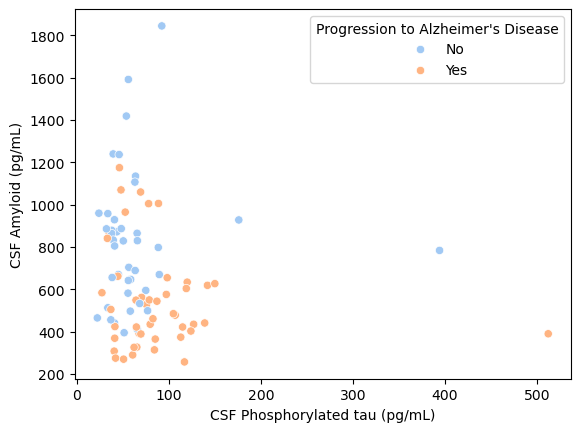

In [18]:

sns.scatterplot(data = df, x='CSF Phosphorylated tau (pg/mL)', y='CSF Amyloid (pg/mL)', hue="Progression to Alzheimer's Disease")
plt.savefig(f"images/amyloid_tau", dpi=300, bbox_inches="tight")
plt.show()

We are going to look at the Mayo Clinic's hypothesis, CSF Phosphorylated tau (pg/mL), CSF Total tau (pg/mL), CSF Amyloid (pg/mL). Testing each value with the same metric - StandardScaler/LogistitRegression, and once the best parameters are determined, we pick the best classifier method.

# Modeling

Two independent training approaches were tried on this data:

- **[`logistic_regression_pipeline.ipynb`](logistic_regression_pipeline.ipynb)** — exhaustive search over all 127 non-empty feature subsets (evaluated with plain Logistic Regression), then a 7-algorithm comparison on the winning pair (CSF Amyloid + CSF Phosphorylated tau), then hyperparameter tuning (scored on F2). Logistic Regression wins at every stage; final holdout: 77.8% accuracy, 8/10 progressors caught (FNR 20%).
- **[`svm_pipeline.ipynb`](svm_pipeline.ipynb)** — all 7 raw features, 7-algorithm `GridSearchCV` comparison (scored on F2) plus a soft-voting ensemble of all seven. SVM (RBF) wins; final holdout: 72.2% accuracy, 9/10 progressors caught (FNR 10%).

See `NARRATIVE.md` for the full story of why these two pipelines land on different winners. Both notebooks save a deployable model; the Ensemble section below loads both and averages their predictions.

## Ensemble: averaging with the SVM (RBF) model from `svm_pipeline.ipynb`

`svm_pipeline.ipynb` took a different route to the same problem: all 7 raw features, `GridSearchCV` scored on F2, and it landed on a tuned SVM (RBF) (`C=0.1`, `gamma='scale'`) instead of Logistic Regression. Rather than pick one winner, deploy both and average their predicted probabilities — a two-model soft-voting ensemble, the same idea as the `VotingClassifier(voting='soft')` used there, but across two independently-tuned pipelines with different feature sets instead of within one.

Both models are trained and saved in their own notebooks; this section only loads the two saved artifacts (run `logistic_regression_pipeline.ipynb` and `svm_pipeline.ipynb` first).

In [19]:
import joblib

# Loads the SVM model svm_pipeline.ipynb trained and saved (C=0.1, gamma='scale', all 7 features)
svm_model = joblib.load('svm_progression_model.joblib')
svm_features = joblib.load('svm_progression_model_features.joblib')
print("Loaded SVM model from svm_progression_model.joblib")

Loaded SVM model from svm_progression_model.joblib


### Ensemble prediction function

Loads both saved models and averages their predicted probabilities. `new_patients_df` needs all 7 raw columns, since the SVM half needs the full feature set even though the LR half only uses 2 of them.

In [20]:
import joblib
import pandas as pd

# LR model + features saved by logistic_regression_pipeline.ipynb
lr_model = joblib.load('alzheimers_progression_model.joblib')
lr_features = joblib.load('alzheimers_progression_model_features.joblib')

# svm_model / svm_features already loaded above, from svm_pipeline.ipynb

# svm_pipeline.ipynb renames columns to short lowercase names before fitting
# (age, mmse, amyloid, total_tau, tau, sex, apoe4); new_patients_df here uses the
# original raw column names, so bridge the two naming conventions before selecting.
svm_column_rename = {
    'Age': 'age',
    'MMSE': 'mmse',
    'CSF Amyloid (pg/mL)': 'amyloid',
    'CSF Total tau (pg/mL)': 'total_tau',
    'CSF Phosphorylated tau (pg/mL)': 'tau',
    'Sex': 'sex',
    'APOE4': 'apoe4',
}

def predict_progression_ensemble(new_patients_df, threshold=0.5):
    # Average the LR (2-feature) and SVM (7-feature) probabilities
    lr_proba = lr_model.predict_proba(new_patients_df[lr_features])[:, 1]
    svm_input = new_patients_df.rename(columns=svm_column_rename)[svm_features]
    svm_proba = svm_model.predict_proba(svm_input)[:, 1]
    avg_proba = (lr_proba + svm_proba) / 2

    return pd.DataFrame({
        'lr_probability': lr_proba,
        'svm_probability': svm_proba,
        'ensemble_probability': avg_proba,
        'predicted_progression': (avg_proba >= threshold).astype(int),
    }, index=new_patients_df.index)

### Trying it on the same example profiles

Same amyloid / phosphorylated-tau values as the LR-only examples above; the other 5 features are held at the dataset median (Age, MMSE, Total tau) or mode (Sex, APOE4) so both models can score the same patients.

In [21]:
feature_cols_full = ['Age', 'MMSE', 'CSF Amyloid (pg/mL)', 'CSF Total tau (pg/mL)', 'CSF Phosphorylated tau (pg/mL)', 'Sex', 'APOE4']

test_array_full = [
    [73, 27, 368.2,  332.0, 119.2, 0, 0],   # High-risk profile
    [73, 27, 604.0,  332.0, 63.5,  0, 0],   # Median profile
    [73, 27, 1062.0, 332.0, 37.1,  0, 0],   # Low-risk profile
    [73, 27, 257.0,  332.0, 512.0, 0, 0],   # Extreme AD-like
    [73, 27, 1845.0, 332.0, 22.4,  0, 0],   # Extreme low-risk
]
test_labels_full = ['High-risk profile', 'Median profile', 'Low-risk profile', 'Extreme AD-like', 'Extreme low-risk']

test_patients_full = pd.DataFrame(test_array_full, columns=feature_cols_full, index=test_labels_full)
predict_progression_ensemble(test_patients_full)

,lr_probability,svm_probability,ensemble_probability,predicted_progression
High-risk profile,0.808273,0.432611,0.620442,1
Median profile,0.564139,0.243276,0.403707,0
Low-risk profile,0.175067,0.129609,0.152338,0
Extreme AD-like,0.984804,0.560897,0.772851,1
Extreme low-risk,0.011423,0.310405,0.160914,0


### Precision-recall and ROC curves for the ensemble

The example profiles above use a fixed `threshold=0.5` to turn the averaged probability into a Yes/No prediction. Borrowing the approach from `capstone_recall_precision.ipynb` (precision-recall and ROC curves swept across every threshold, rather than reporting a single point), evaluate that choice on the same 18-patient holdout both pipeline notebooks used (`test_size=0.2`, `stratify=y`, `random_state=42` — identical split in both, since it's applied to the same 89 rows in the same order).

In [22]:
from sklearn.model_selection import train_test_split

# Same MCI filtering/imputation/encoding as both pipeline notebooks, all 7 raw-named features
mci_full = df[df["Progression to Alzheimer's Disease"].notna()].copy()
numeric_cols = ['Age', 'MMSE', 'CSF Amyloid (pg/mL)', 'CSF Total tau (pg/mL)', 'CSF Phosphorylated tau (pg/mL)']
for col in numeric_cols:
    mci_full[col] = mci_full[col].fillna(mci_full[col].median())
mci_full['APOE4'] = mci_full['APOE4'].fillna(mci_full['APOE4'].mode()[0])
mci_full['Sex'] = (mci_full['Sex'] == 'Male').astype(int)
mci_full['APOE4'] = (mci_full['APOE4'] == 'Yes').astype(int)
mci_full['Target'] = (mci_full["Progression to Alzheimer's Disease"] == 'Yes').astype(int)

ensemble_feature_cols = numeric_cols + ['Sex', 'APOE4']
X_full = mci_full[ensemble_feature_cols]
y_full = mci_full['Target']

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_full, y_full, test_size=0.2, stratify=y_full, random_state=42
)
print(f"Holdout size: {len(X_test_h)}  ({y_test_h.sum()} Yes / {len(y_test_h) - y_test_h.sum()} No)")

ensemble_results = predict_progression_ensemble(X_test_h)
ensemble_proba = ensemble_results['ensemble_probability'].values

Holdout size: 18  (10 Yes / 8 No)


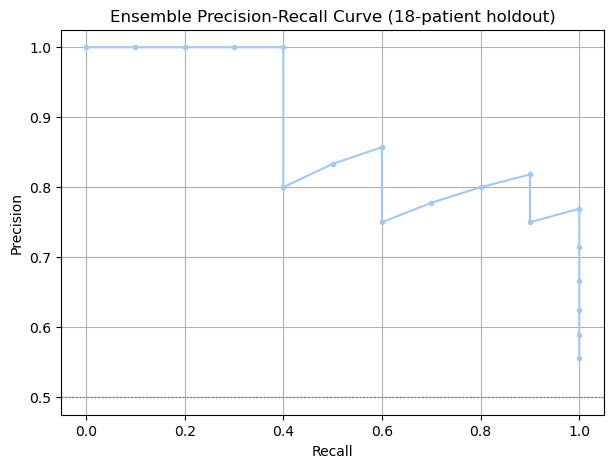

In [23]:
from sklearn.metrics import precision_recall_curve, roc_curve, auc

precision, recall, pr_thresholds = precision_recall_curve(y_test_h, ensemble_proba)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, '-o', markersize=3)
plt.axhline(0.5, color='gray', linestyle=':', linewidth=1)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Ensemble Precision-Recall Curve (18-patient holdout)')
plt.grid(True)
plt.savefig("images/ensemble_precision_recall.png", dpi=300, bbox_inches="tight")
plt.show()

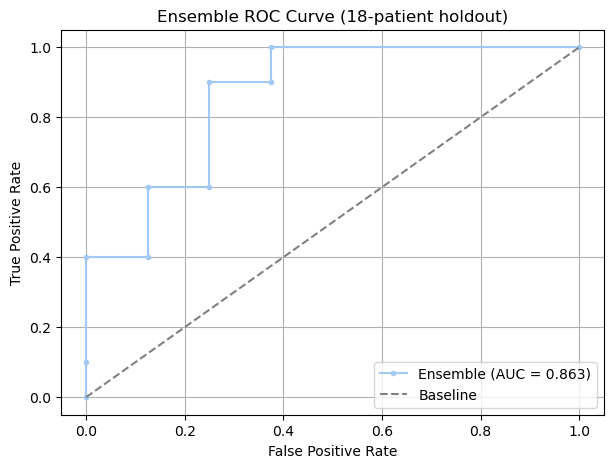

In [24]:
fpr, tpr, roc_thresholds = roc_curve(y_test_h, ensemble_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, '-o', markersize=3, label=f'Ensemble (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Ensemble ROC Curve (18-patient holdout)')
plt.legend()
plt.grid(True)
plt.savefig("images/ensemble_roc.png", dpi=300, bbox_inches="tight")
plt.show()